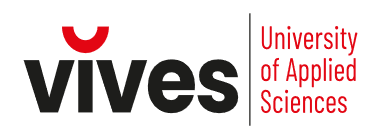<br>


**MACHINE LEARNING FUNDAMENTALS**<br>
APPLIED COMPUTER SCIENCE<br>
Specialization in Artificial Intelligence<br>
Andy Louwyck

---



---



# **EVALUATION METRICS FOR CLASSIFICATION: EXERCISES**

## Exercise 1

Define a class `Metrics` that calculates the following metrics in separate methods:

- Confusion Matrix
- Accuracy
- Recall
- Precision
- $F_1$-score
- $F_\beta$-score
- Sensitivity
- Specificity
- True Positive Rate
- False Positive Rate
- True Negative Rate
- False Negative Rate

Do NOT use scikit-learn here!

The constructor must be given the labels `y` and the predictions `yp`, which are then stored in attributes with the same name.

First calculate the True Positives, True Negatives, False Positives and False Negatives. Put these in the respective attributes `TP`, `TN`, `FP` and `FN`. Based on these values, all requested metrics can then be easily calculated.

Put the confusion matrix in a Pandas `DataFrame` and add the totals to it as well. Also provide a print method that nicely lists all other metrics. Provide an input parameter `ndigits` that determines the number of digits after the decimal point and is 2 by default.

In [1]:
# implement class Metrics

import numpy as np
import pandas as pd

class Metrics:

    def __init__(self, y, yp):
        self.y = y.astype(int)
        self.yp = yp.astype(int)
        self.n = len(y)
        # calculate TP, TN, FP, FP
        yp_is_pos = yp == 1
        yp_is_neg = yp == 0
        self.TP = np.sum(self.yp[yp_is_pos] == self.y[yp_is_pos])
        self.TN = np.sum(self.yp[yp_is_neg] == self.y[yp_is_neg])
        self.FP = np.sum(self.yp[yp_is_pos] != self.y[yp_is_pos])
        self.FN = np.sum(self.yp[yp_is_neg] != self.y[yp_is_neg])

    def confusion_matrix(self):
        cm = np.array([[self.TP, self.FN], [self.FP, self.TN]])
        cm = np.hstack((cm, cm.sum(axis=1, keepdims=True)))
        cm = np.vstack((cm, cm.sum(axis=0, keepdims=True)))
        return pd.DataFrame(data=cm,
                            columns=["Predicted Pos", "Predicted Neg", "Total"],
                            index=['Actual Pos', 'Actual Neg', 'Total'])

    def accuracy(self):
        return np.sum(self.y == self.yp) / self.n

    def recall(self):
        return self.TP / (self.TP + self.FN)

    def precision(self):
        return self.TP / (self.TP + self.FP)

    def Fbeta(self, beta):
        P = self.precision()
        R = self.recall()
        b2 = beta**2
        return (1 + b2) * P * R / (b2* P + R)

    def F1(self):
        return self.Fbeta(1)

    def sensitivity(self):
        return self.recall()

    def specificity(self):
        return self.TN / (self.TN + self.FP)

    def TNR(self):
        return self.specificity()

    def TPR(self):
        return self.sensitivity()

    def FPR(self):
        return self.FP / (self.FP + self.TN)

    def FNR(self):
        return self.FN / (self.FN + self.TP)

    def print(self, ndigits=2):
        for metric in ['accuracy', 'recall', 'precision', 'F1',
                       'sensitivity', 'specificity', 'TPR', 'TNR', 'FPR', 'FNR']:
            score = getattr(self, metric)()
            print(f"{metric} = {score:.{ndigits}f}")

Then use your class `Metrics` to calculate and print all these metrics for the datasets below, where the first class 'spam' is the 'positive' class.

Study the results so that you get a feel for the different metrics. Also come up with your own datasets and study the metrics!

Tip: first write a generic function that converts the data about the datasets to labels `y` and predictions `yp`.

In [2]:
# generic function converting dataset to labels y and predictions yp

def create_y_yp(pos_tot, pos_mis, neg_tot, neg_mis):
    # pos_tot: total of positives (y=1)
    # pos_mis: misclassified positives (y=1, yp=0)
    # neg_tot: total of negatives (y=0)
    # neg_mis: misclassified negatives (y=0, yp=1)
    y = np.zeros(pos_tot + neg_tot)
    y[:pos_tot] = 1
    yp = np.zeros(y.shape)
    n = pos_tot - pos_mis
    yp[:n] = 1
    n = pos_tot + neg_mis
    yp[pos_tot:n] = 1
    return y, yp

In [3]:
# test function

# put y and yp next to each other in a 2D matrix
concat = lambda y, yp: np.hstack((y[:, np.newaxis], yp[:, np.newaxis]))

print('all classified correctly:')
y, yp = create_y_yp(5, 0, 5, 0)
print(concat(y, yp))
print()
print('all misclassified:')
y, yp = create_y_yp(5, 5, 5, 5)
print(concat(y, yp))
print()
print('1 positive and 2 negatives misclassified:')
y, yp = create_y_yp(5, 1, 5, 2)
print(concat(y, yp))

all classified correctly:
[[1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]]

all misclassified:
[[1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]]

1 positive and 2 negatives misclassified:
[[1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [0. 0.]
 [0. 0.]
 [0. 0.]]


In [4]:
# additionally define a function to calculate and print the metrics using class Metrics

def metrics(y, yp):
    m = Metrics(y, yp)
    m.print(3)
    return m.confusion_matrix()

Dataset 1:
  - spam:
    - total: 4
    - misclassified: 1
  - ham:
    - total: 6
    - misclassified: 2

In [5]:
y, yp = create_y_yp(4, 1, 6, 2)
metrics(y, yp)

accuracy = 0.700
recall = 0.750
precision = 0.600
F1 = 0.667
sensitivity = 0.750
specificity = 0.667
TPR = 0.750
TNR = 0.667
FPR = 0.333
FNR = 0.250


,Predicted Pos,Predicted Neg,Total
Actual Pos,3,1,4
Actual Neg,2,4,6
Total,5,5,10


Dataset 2:
- spam:
  - total: 50
  - misclassified: 0
- ham:
  - total: 950
  - misclassified: 0

In [6]:
# the perfect classifier
y, yp = create_y_yp(50, 0, 950, 0)
metrics(y, yp)

accuracy = 1.000
recall = 1.000
precision = 1.000
F1 = 1.000
sensitivity = 1.000
specificity = 1.000
TPR = 1.000
TNR = 1.000
FPR = 0.000
FNR = 0.000


,Predicted Pos,Predicted Neg,Total
Actual Pos,50,0,50
Actual Neg,0,950,950
Total,50,950,1000


Dataset 3:
  - spam:
    - total: 50
    - misclassified: 50
  - ham:
    - total: 950
    - misclassified: 950

In [7]:
y, yp = create_y_yp(50, 50, 950, 950)
metrics(y, yp)

accuracy = 0.000
recall = 0.000
precision = 0.000
F1 = nan
sensitivity = 0.000
specificity = 0.000
TPR = 0.000
TNR = 0.000
FPR = 1.000
FNR = 1.000


<ipython-input-1-7314b7699326>:41: RuntimeWarning: invalid value encountered in scalar divide
  return (1 + b2) * P * R / (b2* P + R)


,Predicted Pos,Predicted Neg,Total
Actual Pos,0,50,50
Actual Neg,950,0,950
Total,950,50,1000


In [8]:
# the 'reversed' classifier -> reverse predictions to get the perfect classifier!
yp = 1 - yp
metrics(y, yp)

accuracy = 1.000
recall = 1.000
precision = 1.000
F1 = 1.000
sensitivity = 1.000
specificity = 1.000
TPR = 1.000
TNR = 1.000
FPR = 0.000
FNR = 0.000


,Predicted Pos,Predicted Neg,Total
Actual Pos,50,0,50
Actual Neg,0,950,950
Total,50,950,1000


Dataset 4:
- spam:
  - total: 50
  - misclassified: 50
- ham:
  - total: 950
  - misclassified: 0

In [9]:
# classifier predicting only negatives, so TP = FP = 0
y, yp = create_y_yp(50, 50, 950, 0)
metrics(y, yp)

accuracy = 0.950
recall = 0.000
precision = nan
F1 = nan
sensitivity = 0.000
specificity = 1.000
TPR = 0.000
TNR = 1.000
FPR = 0.000
FNR = 1.000


<ipython-input-1-7314b7699326>:35: RuntimeWarning: invalid value encountered in scalar divide
  return self.TP / (self.TP + self.FP)


,Predicted Pos,Predicted Neg,Total
Actual Pos,0,50,50
Actual Neg,0,950,950
Total,0,1000,1000


Dataset 5:
  - spam:
    - total: 50
    - misclassified: 0
  - ham:
    - total: 950
    - misclassified: 950

In [10]:
# classifier predicting only positives, so TN = FN = 0
y, yp = create_y_yp(50, 0, 950, 950)
metrics(y, yp)

accuracy = 0.050
recall = 1.000
precision = 0.050
F1 = 0.095
sensitivity = 1.000
specificity = 0.000
TPR = 1.000
TNR = 0.000
FPR = 1.000
FNR = 0.000


,Predicted Pos,Predicted Neg,Total
Actual Pos,50,0,50
Actual Neg,950,0,950
Total,1000,0,1000


Data set 6:
  - spam:
    - total: 50
    - misclassified: 2
  - ham:
    - total: 950
    - misclassified: 16

In [11]:
y, yp = create_y_yp(50, 2, 950, 16)
metrics(y, yp)

accuracy = 0.982
recall = 0.960
precision = 0.750
F1 = 0.842
sensitivity = 0.960
specificity = 0.983
TPR = 0.960
TNR = 0.983
FPR = 0.017
FNR = 0.040


,Predicted Pos,Predicted Neg,Total
Actual Pos,48,2,50
Actual Neg,16,934,950
Total,64,936,1000


Data set 7:
  - spam:
    - total: 50
    - misclassified: 48
  - ham:
    - total: 950
    - misclassified: 3

In [12]:
y, yp = create_y_yp(50, 48, 950, 3)
metrics(y, yp)

accuracy = 0.949
recall = 0.040
precision = 0.400
F1 = 0.073
sensitivity = 0.040
specificity = 0.997
TPR = 0.040
TNR = 0.997
FPR = 0.003
FNR = 0.960


,Predicted Pos,Predicted Neg,Total
Actual Pos,2,48,50
Actual Neg,3,947,950
Total,5,995,1000


Dataset 8:
- spam:
  - total: 500
  - misclassified: 324
- ham:
  - total: 500
  - misclassified: 23

In [14]:
y, yp = create_y_yp(500, 324, 500, 23)
metrics(y, yp)

accuracy = 0.653
recall = 0.352
precision = 0.884
F1 = 0.504
sensitivity = 0.352
specificity = 0.954
TPR = 0.352
TNR = 0.954
FPR = 0.046
FNR = 0.648


,Predicted Pos,Predicted Neg,Total
Actual Pos,176,324,500
Actual Neg,23,477,500
Total,199,801,1000


Data set 9:
  - spam:
    - total: 500
    - misclassified: 13
  - ham:
    - total: 500
    - misclassified: 402

In [15]:
y, yp = create_y_yp(500, 13, 500, 402)
metrics(y, yp)

accuracy = 0.585
recall = 0.974
precision = 0.548
F1 = 0.701
sensitivity = 0.974
specificity = 0.196
TPR = 0.974
TNR = 0.196
FPR = 0.804
FNR = 0.026


,Predicted Pos,Predicted Neg,Total
Actual Pos,487,13,500
Actual Neg,402,98,500
Total,889,111,1000


Dataset 10:
- spam:
  - total: 500
  - misclassified: 1
- ham:
  - total: 500
  - misclassified: 499

In [16]:
y, yp = create_y_yp(500, 1, 500, 499)
metrics(y, yp)

accuracy = 0.500
recall = 0.998
precision = 0.500
F1 = 0.666
sensitivity = 0.998
specificity = 0.002
TPR = 0.998
TNR = 0.002
FPR = 0.998
FNR = 0.002


,Predicted Pos,Predicted Neg,Total
Actual Pos,499,1,500
Actual Neg,499,1,500
Total,998,2,1000


## Exercise 2

Consider the confusion matrix below.

```python
[[283, 43],
 [17, 257]]
```

In this case, the rows represent the predicted labels and the columns the actual labels. How can you quickly swap that? In other words, how can you quickly put the predictions in the columns and the actual labels in the rows? Or how can you swap the False Negatives and False Positives with one command?

In [25]:
# simply transpose the matrix (when it is a numpy array!)
import numpy as np

cm = np.array([[283, 43],
               [17, 257]])

cm.T  # invoke ".T" to transpose

array([[283,  17],
       [ 43, 257]])

Now calculate the different metrics. Define a class `ConfusionMatrix` that accepts a NumPy array (with true labels in the rows and predictions in the columns) and calculates all metrics based on this array. Use the NumPy array method `sum`. Also provide a method `to_dataframe` that converts the input array to a Pandas `DataFrame` and adds the totals to it. Of course, you can also define a `print` method that prints out all metrics nicely.

In [23]:
# implement class ConfusionMatrix

import pandas as pd

class ConfusionMatrix:

    def __init__(self, matrix):
        self.matrix = np.array(matrix)

    def to_dataframe(self):
        cm = np.hstack((self.matrix, self.matrix.sum(axis=1, keepdims=True)))
        cm = np.vstack((cm, cm.sum(axis=0, keepdims=True)))
        return pd.DataFrame(data=cm,
                            columns=["Predicted Pos", "Predicted Neg", "Total"],
                            index=['Actual Pos', 'Actual Neg', 'Total'])

    def accuracy(self):
        return np.diag(self.matrix).sum() / self.matrix.sum()

    def recall(self):
        return self.matrix[0, 0] / self.matrix[0, :].sum()

    def precision(self):
        return self.matrix[0, 0] / self.matrix[:, 0].sum()

    def Fbeta(self, beta):
        P = self.precision()
        R = self.recall()
        b2 = beta**2
        return (1 + b2) * P * R / (b2* P + R)

    def F1(self):
        return self.Fbeta(1)

    def sensitivity(self):
        return self.recall()

    def specificity(self):
        return self.matrix[1, 1] / self.matrix[1, :].sum()

    def TNR(self):
        return self.specificity()

    def TPR(self):
        return self.sensitivity()

    def FPR(self):
        return self.matrix[1, 0] / self.matrix[1, :].sum()

    def FNR(self):
        return self.matrix[0, 1] / self.matrix[0, :].sum()

    def print(self, ndigits=2):
        for metric in ['accuracy', 'recall', 'precision', 'F1',
                       'sensitivity', 'specificity', 'TPR', 'TNR', 'FPR', 'FNR']:
            score = getattr(self, metric)()
            print(f"{metric} = {score:.{ndigits}f}")

In [26]:
# apply class ConfusionMatrix to given confusion matrix
cm = ConfusionMatrix(cm.T)  # transpose!
cm.to_dataframe()

,Predicted Pos,Predicted Neg,Total
Actual Pos,283,17,300
Actual Neg,43,257,300
Total,326,274,600


In [27]:
# print metrics
cm.print(5)

accuracy = 0.90000
recall = 0.94333
precision = 0.86810
F1 = 0.90415
sensitivity = 0.94333
specificity = 0.85667
TPR = 0.94333
TNR = 0.85667
FPR = 0.14333
FNR = 0.05667


Finally, check whether the metrics accuracy, recall, precision and $F_1$-score are calculated correctly by using functions from Scikit-Learn, and also check how the confusion matrix is constructed by Scikit-Learn.

In [28]:
# sklearn metrics
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

In [29]:
# use function create_y_yp() from exercise 1 to determine y and y_pred
def create_y_yp(pos_tot, pos_mis, neg_tot, neg_mis):
    y = np.zeros(pos_tot + neg_tot)
    y[:pos_tot] = 1
    yp = np.zeros(y.shape)
    n = pos_tot - pos_mis
    yp[:n] = 1
    n = pos_tot + neg_mis
    yp[pos_tot:n] = 1
    return y, yp

In [30]:
# create true and predicted labels y and yp
y, yp = create_y_yp(pos_tot=cm.matrix[0, :].sum(),
                    pos_mis=cm.matrix[0, 1],
                    neg_tot=cm.matrix[1, :].sum(),
                    neg_mis=cm.matrix[1, 0])

In [31]:
# apply sklearn score functions to verify
for metric in [accuracy_score, recall_score, precision_score, f1_score]:
    score = metric(y_true=y, y_pred=yp)
    print(f"{metric.__name__} = {score:.5f}")

accuracy_score = 0.90000
recall_score = 0.94333
precision_score = 0.86810
f1_score = 0.90415


[[283  17]
 [ 43 257]]



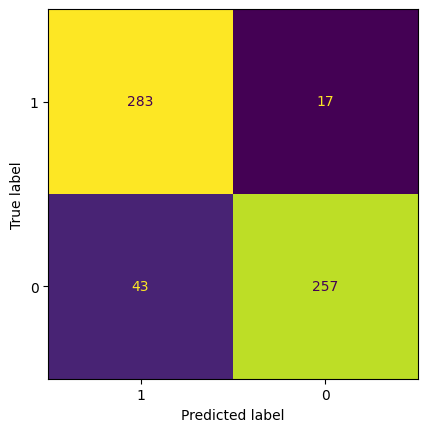

In [32]:
# sklearn also puts actual labels in the rows and predictions in the columns!
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print(confusion_matrix(y, yp, labels=[1, 0]))  # set labels to put 1 on top!
print()

ConfusionMatrixDisplay.from_predictions(y_true=y, y_pred=yp, labels=[1, 0], colorbar=False);

## Exercise 3

In this exercise, we'll generate four fictitious datasets containing information about the age, salary, and risk level of clients of an insurance company. The datasets are written to four JSON files:

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(0)

r1 = 10
theta1 = np.pi / 3
theta2 = np.pi / 3

for i, r2 in enumerate([17, 14, 12, 10]):

    x1 = r1 * np.cos(theta1) + np.random.randn(1000)
    y1 = r1 * np.sin(theta1) + np.random.randn(1000)

    x2 = r2 * np.cos(theta2) + np.random.randn(1000)
    y2 = r2 * np.sin(theta2) + np.random.randn(1000)

    x1 *= 6
    x2 *= 6
    y1 *= 250
    y2 *= 250

    x1, x2, y1, y2 = np.round(x1), np.round(x2), np.round(y1), np.round(y2)

    dx = 18 - x1.min()  # minimum 18 years old
    x1 += dx
    x2 += dx

    df = pd.DataFrame(dict(
        age=np.hstack((x1, x2)),
        salary=np.hstack((y1, y2)),
        risico=['low'] * 1000 + ['high'] * 1000
    ))

    df.to_json("insurance_" + str(i+1) + ".json", orient="table", index=False)

Now read the JSON files with fictitious data:

- `insurance_1.json`
- `insurance_2.json`
- `insurance_3.json`
- `insurance_4.json`

Plot the datasets using a scatterplot. On the X-axis you put the `'age'`, on the Y-axis the monthly `'salary'`. Give the data points with `'low'` risk a green color, those with `'high'` risk a red color.

Then train a Logistic Regression model on each dataset using Scikit-Learn. Do not apply regularization. It is also not necessary to split your dataset. Add the obtained separating line to the scatterplot of the dataset each time.

Evaluate each model by creating the confusion matrix and calculating the following metrics:

- accuracy
- recall
- precision
- $F_1$-score

Use Scikit-Learn functions here as well.

Finally, plot the ROC curve for each model. Add to this plot the diagonal corresponding to the random classifier. Indicate the point closest to FPR=0 and TPR=1 on the curve, and enter the corresponding optimal threshold in the plot title. Include the AUC in the graph legend.

Tip: Use loops and subplots to reduce programming work!

In [34]:
# import packages, modules, classes and functions
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 125
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import *

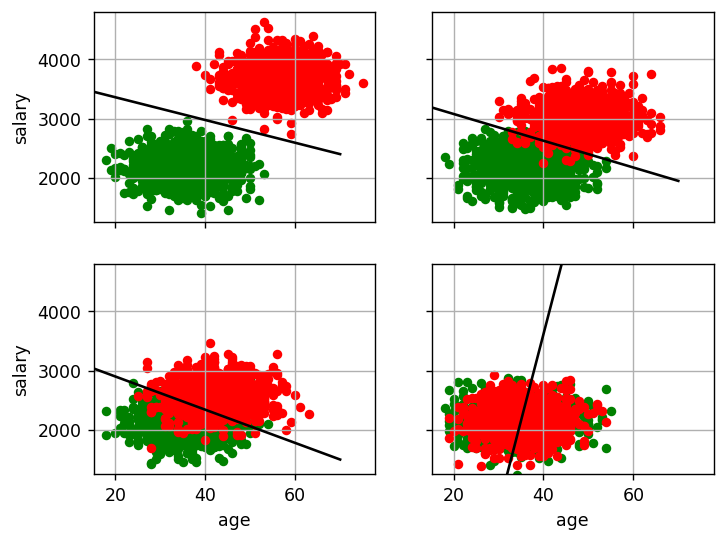

In [45]:
# read datasets, apply logistic regression, and create scatter plots

_, ax = plt.subplots(2, 2, sharex=True, sharey=True)
ax = [ax for row in ax for ax in row]
models = []

for i in range(len(ax)):
    df = pd.read_json("insurance_" + str(i+1) + ".json", orient="table")
    X = df.loc[:, ['age', 'salary']]
    y = (df.risico=='low').astype(int)
    lr = LogisticRegression(penalty=None)
    lr.fit(X, y)
    models.append(lr)
    a, b = lr.coef_[0], lr.intercept_[0]
    x_line = np.array([10, 70])
    y_line = -(x_line * a[0] + b) / a[1]
    df[df.risico=='low'].plot.scatter(x='age', y='salary', c='g', ax=ax[i]);
    df[df.risico=='high'].plot.scatter(x='age', y='salary', c='r', ax=ax[i]);
    if i==0: xl, yl = ax[i].get_xlim(), ax[i].get_ylim()
    ax[i].grid()
    ax[i].plot(x_line, y_line, 'k-');
    ax[i].set_xlim(xl);
    ax[i].set_ylim(yl);

In [37]:
# define function to print metrics and plot ROC curve

def show_metrics(models, i):
    df = pd.read_json("insurance_" + str(i+1) + ".json", orient="table")
    X = df.loc[:, ['age', 'salary']]
    y = (df.risico=='low').astype(int)
    yp = models[i].predict(X)
    p = models[i].predict_proba(X)
    print(confusion_matrix(y, yp))
    print()
    for metric in [accuracy_score, recall_score, precision_score, f1_score]:
        score = metric(y, yp)
        print(f"{metric.__name__} = {score:.5f}")
    print()
    fpr, tpr, thresholds = roc_curve(y, p[:, 1], drop_intermediate=False)
    closest = np.argmin(fpr**2 + (tpr - 1)**2)  # closest to point (0, 1)
    RocCurveDisplay.from_predictions(y, p[:, 1], c='orange')
    plt.plot(fpr[closest], tpr[closest], "ko");
    plt.title(f"threshold = {thresholds[closest]:.3f}")
    plt.plot([0, 1], [0, 1], 'b--');
    plt.grid();

[[1000    0]
 [   0 1000]]

accuracy_score = 1.00000
recall_score = 1.00000
precision_score = 1.00000
f1_score = 1.00000



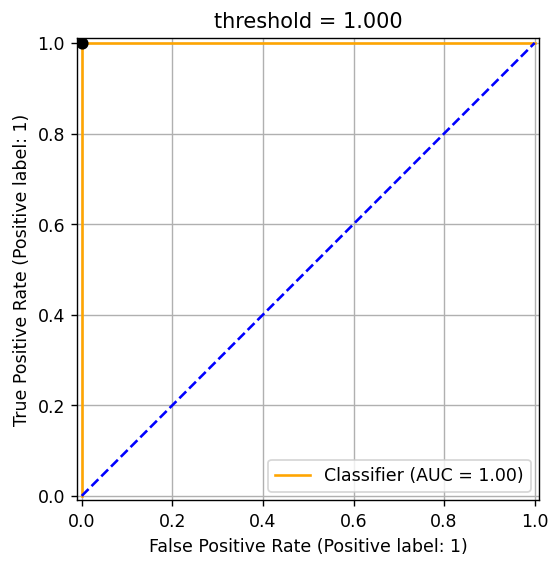

In [38]:
# first dataset and model (= perfect classifier)
show_metrics(models, 0)

[[976  24]
 [ 19 981]]

accuracy_score = 0.97850
recall_score = 0.98100
precision_score = 0.97612
f1_score = 0.97855



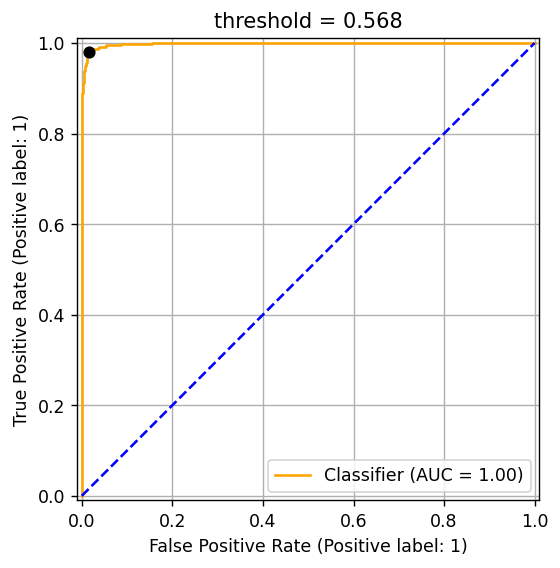

In [39]:
# second dataset and model
show_metrics(models, 1)

[[846 154]
 [155 845]]

accuracy_score = 0.84550
recall_score = 0.84500
precision_score = 0.84585
f1_score = 0.84542



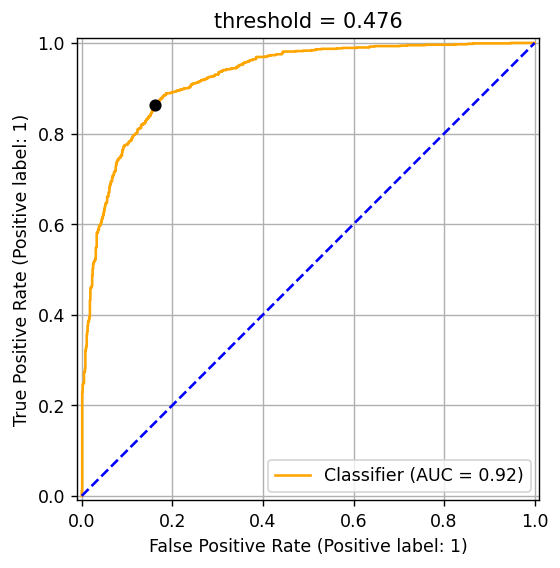

In [40]:
# third dataset and model
show_metrics(models, 2)

[[509 491]
 [457 543]]

accuracy_score = 0.52600
recall_score = 0.54300
precision_score = 0.52515
f1_score = 0.53392



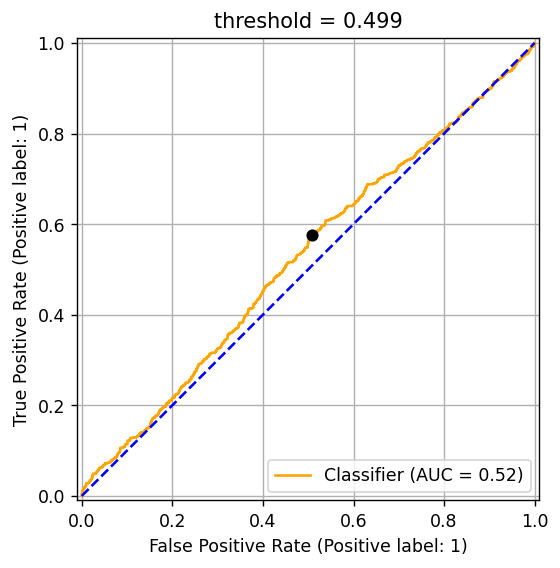

In [41]:
# fourth dataset and model (almost behaves like a random classifier)
show_metrics(models, 3)

---